# Report Sequence :

We have split the dataset into train & test & all analysis that we have performed is on our train set. This has been done so that our decision dont get influenced by datapoints which models might not see during training.

1) Dataset description : <br>
Use outputs of these sections.<br>
&emsp;a) df.describe() <br>
&emsp;b) df.unique() <br>
&emsp;c) df.count() <br>
<br>
2) Univariate Analysis : <br>
Use outputs of these sections.<br>
&emsp; a) Box plots - For numerical <br>
&emsp; b) Histograms - For categorical & numerical. <br>
<br>
3) Multivariate - <br>
Use outputs of these sections.<br>
&emsp; a) Pearson correlation coeff <br>
&emsp; b) Correlation heatmap <br>
<br>
4) Bivariate - Scatter plots & line plots.<br>
5) Handling Missing Values <br>
6) De-duplication : We have observed that the dataset contains high no.of duplicates. We have removed such duplicates before training. <br>
7) Biases in dataset (if any)

Add the observations that are present in this .ipynb file.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/train_data.csv")
df.head()

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native,Possibility
0,35,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,1
1,23,Private,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,United-States,0
2,39,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,60.0,United-States,1
3,33,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,32.0,United-States,0
4,27,Self-emp-inc,HS-grad,9,Separated,Adm-clerical,Not-in-family,White,Male,0,0,38.0,United-States,0


In [ ]:
df.describe()

,age,educationno,capitalgain,capitalloss,hoursperweek,Possibility
count,21112.000000,21112.000000,21112.000000,21112.000000,20794.000000,21112.000000
mean,38.285004,10.129452,1124.986974,87.479585,40.992883,0.248153
std,13.161197,2.552163,7529.845515,401.632019,11.986292,0.431951
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [ ]:
df.nunique()

,0
age,71
workclass,7
education,16
educationno,16
maritalstatus,7
occupation,14
relationship,6
race,5
sex,2
capitalgain,116


In [ ]:
df.count()

,0
age,21112
workclass,21112
education,21112
educationno,21112
maritalstatus,20976
occupation,21112
relationship,21112
race,20636
sex,20883
capitalgain,21112


Some rows have count < 21112. This means they are missing values.

## Univariate Analysis

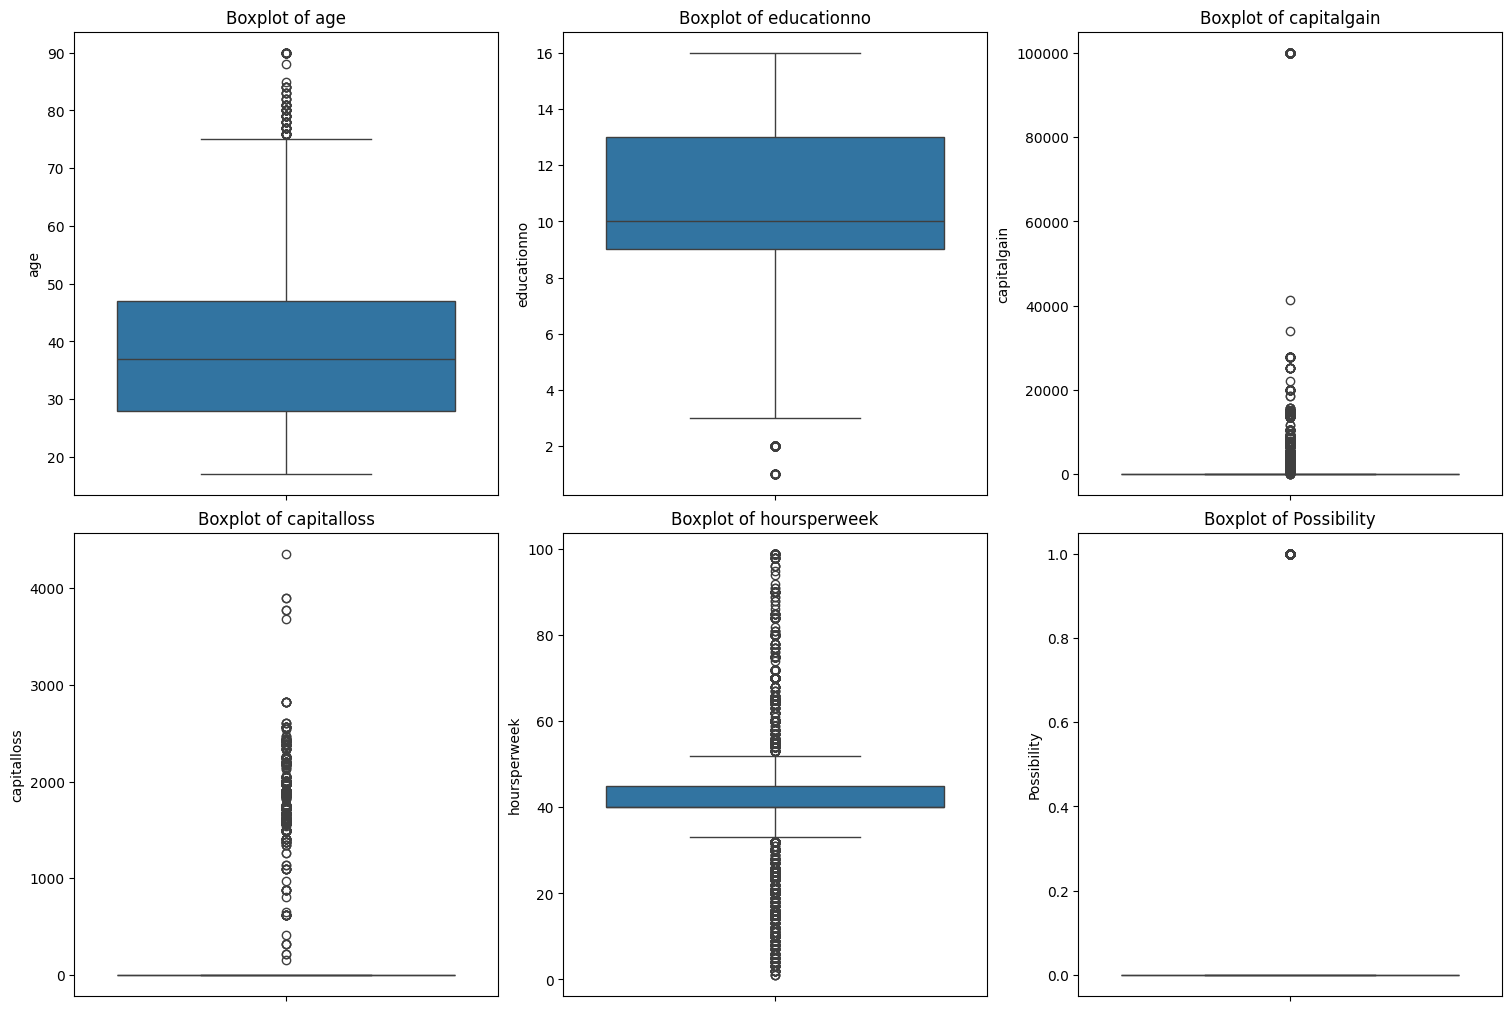

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_features = df.select_dtypes(include=['number']).columns

# Determine the number of features and set up subplots
num_features = len(numerical_features)
num_cols = 3  # Number of columns in subplot grid
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows needed

# Create a figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), constrained_layout=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot boxplots for each numerical feature
for i, feature in enumerate(numerical_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Show the plot
plt.show()

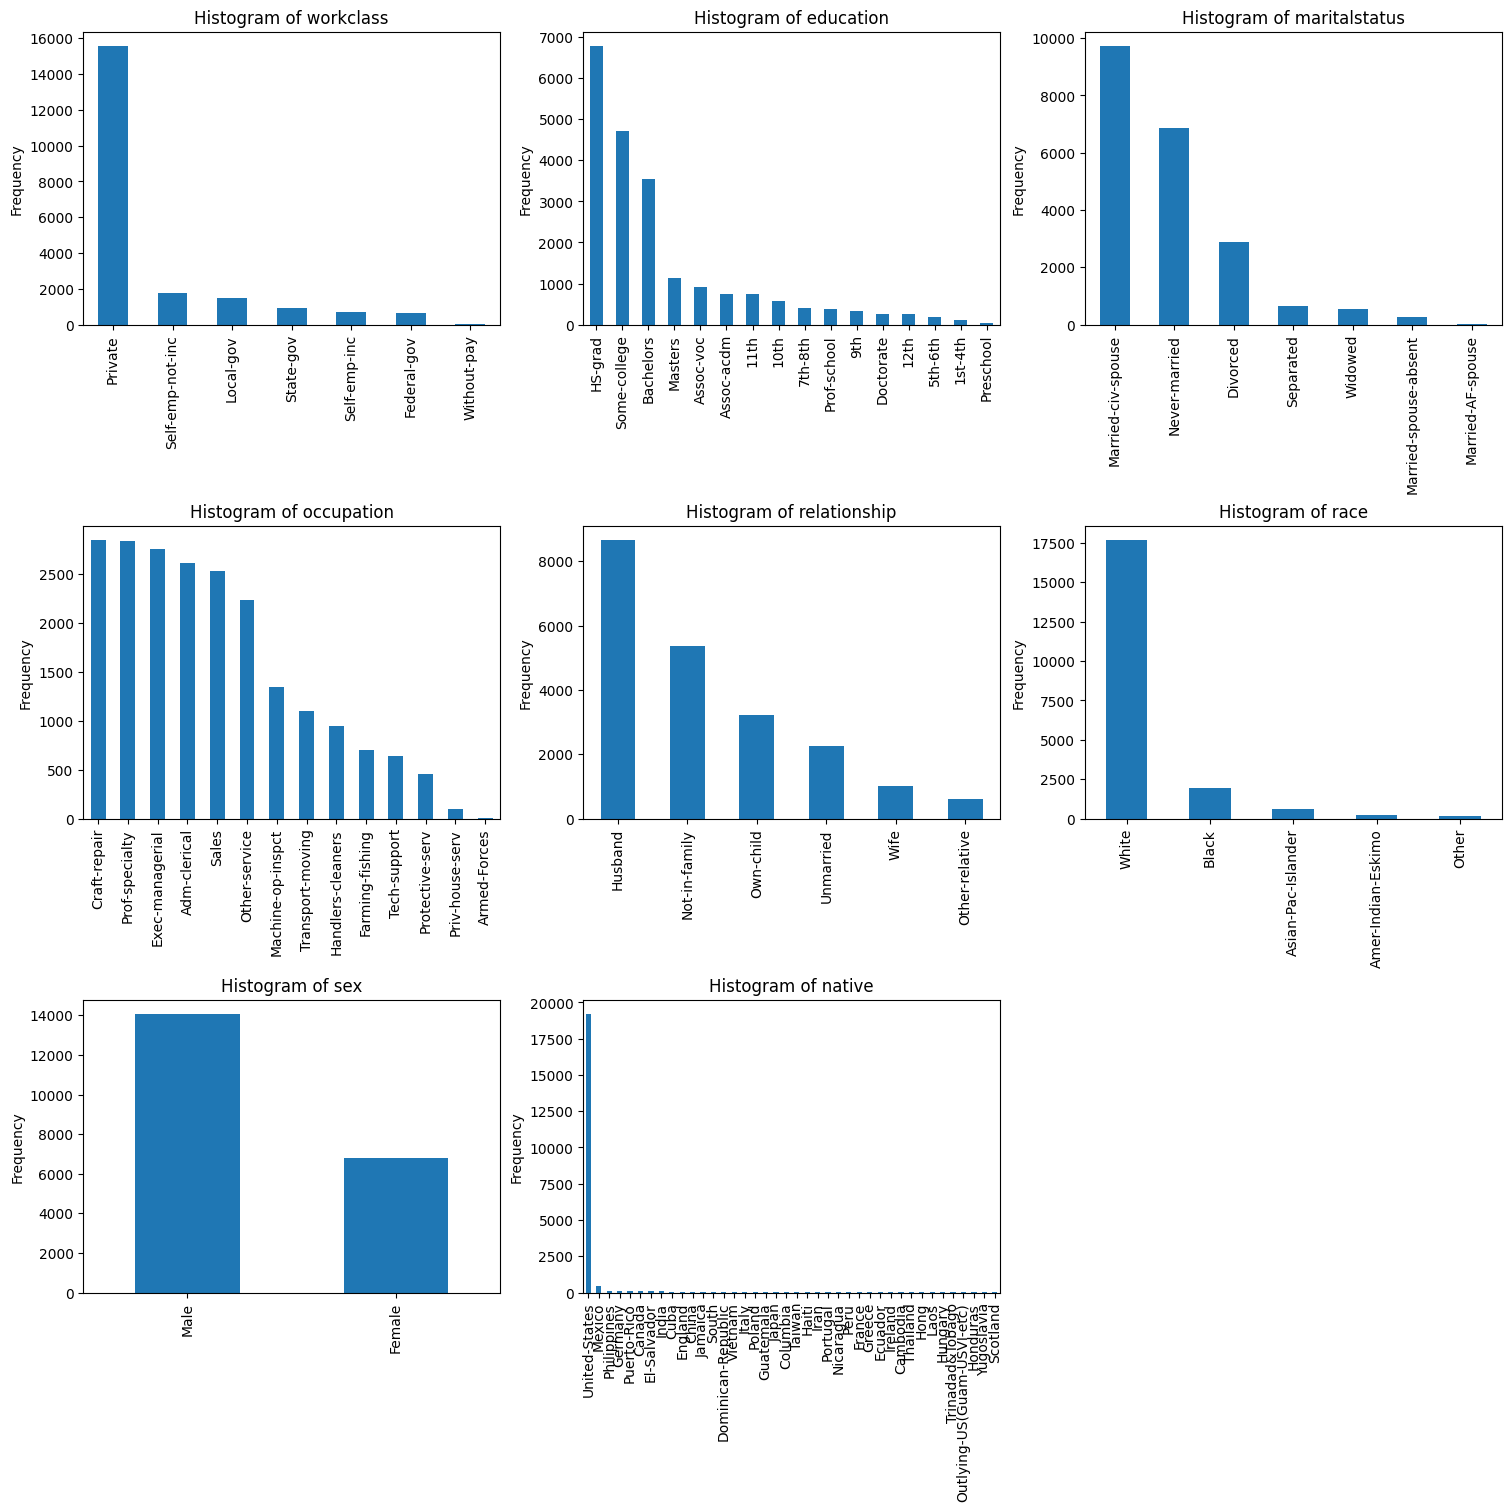

In [ ]:
# Select only categorical columns
categorical_features = df.select_dtypes(include=['object']).columns

# Determine the number of features and set up subplots
num_features = len(categorical_features)
num_cols = 3  # Number of columns in subplot grid
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows needed

# Create a figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), constrained_layout=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot histograms for each categorical feature
for i, feature in enumerate(categorical_features):
    df[feature].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Show the plot
plt.show()

**Observations :-**<br>
1) Most people work in private companies.<br>
2) Presence of high no.of Category - "White". <br>
3) Most people are US citizens,

## Multivariate analysis

In [ ]:
# Compute Pearson correlation matrix for numerical features
correlation_matrix = df.select_dtypes(include=['number']).corr()

print(correlation_matrix)

                   age  educationno  capitalgain  capitalloss  hoursperweek  \
age           1.000000     0.048571     0.085439     0.056397      0.102345   
educationno   0.048571     1.000000     0.132090     0.075064      0.146205   
capitalgain   0.085439     0.132090     1.000000    -0.032543      0.084525   
capitalloss   0.056397     0.075064    -0.032543     1.000000      0.045774   
hoursperweek  0.102345     0.146205     0.084525     0.045774      1.000000   
Possibility   0.247566     0.334027     0.226576     0.140165      0.224251   

              Possibility  
age              0.247566  
educationno      0.334027  
capitalgain      0.226576  
capitalloss      0.140165  
hoursperweek     0.224251  
Possibility      1.000000  


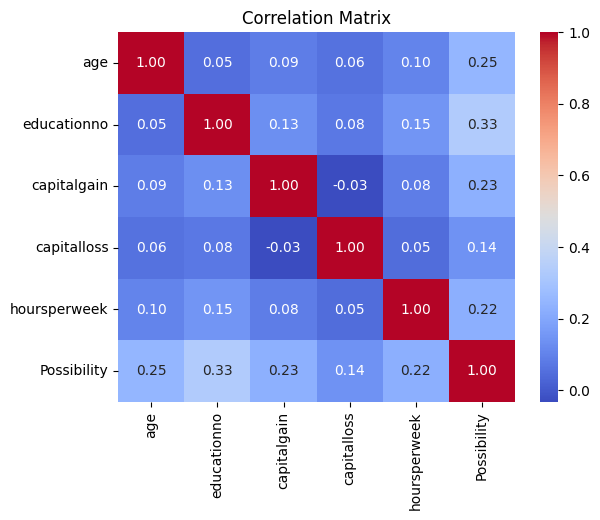

In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Bivariate Analysis
Need to discuss this, plots dont make much sense. No trends found.

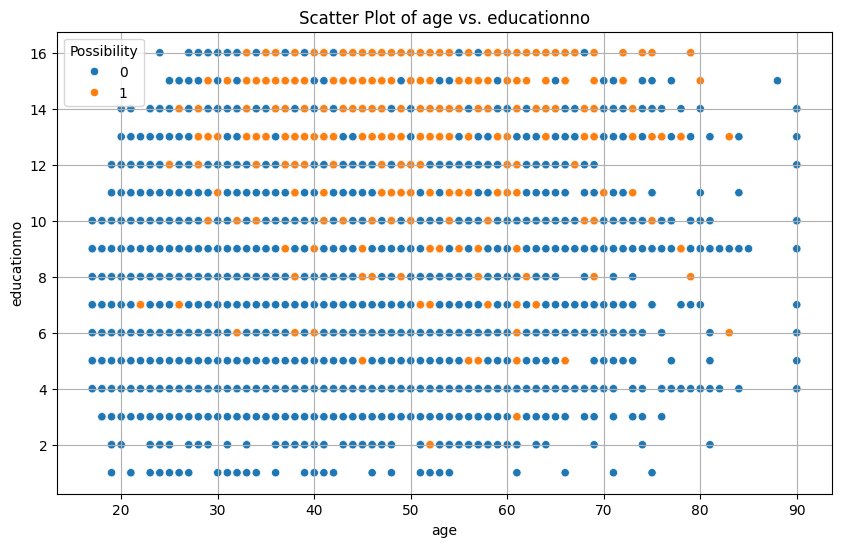

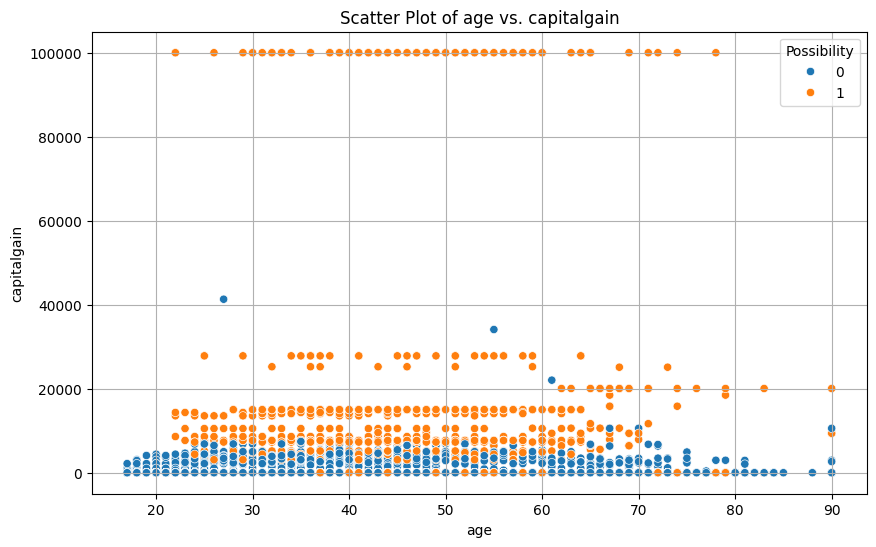

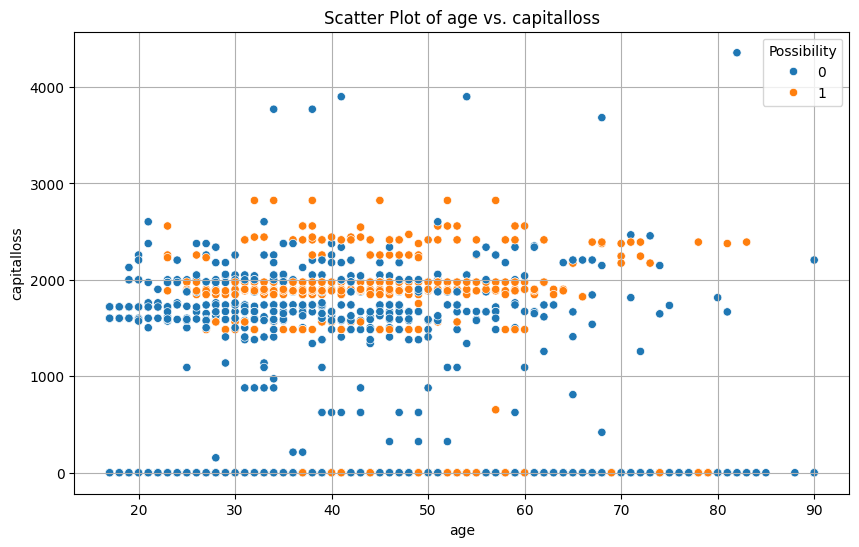

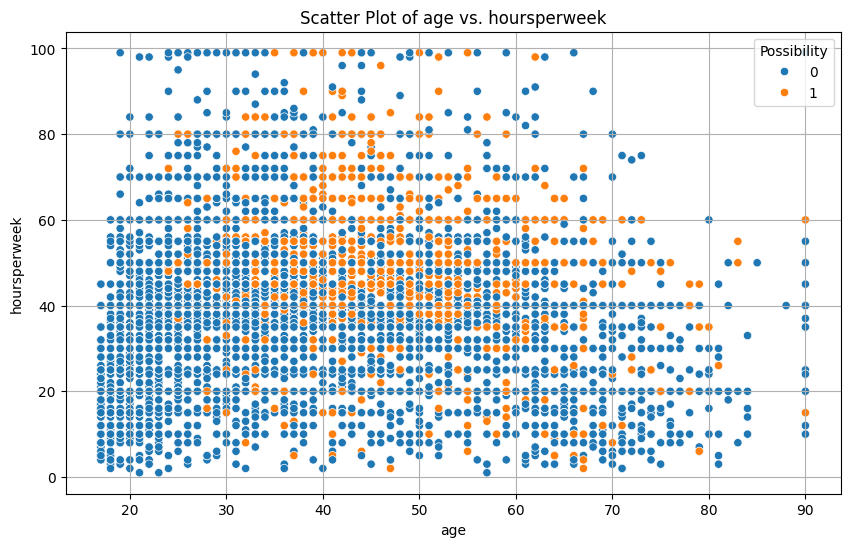

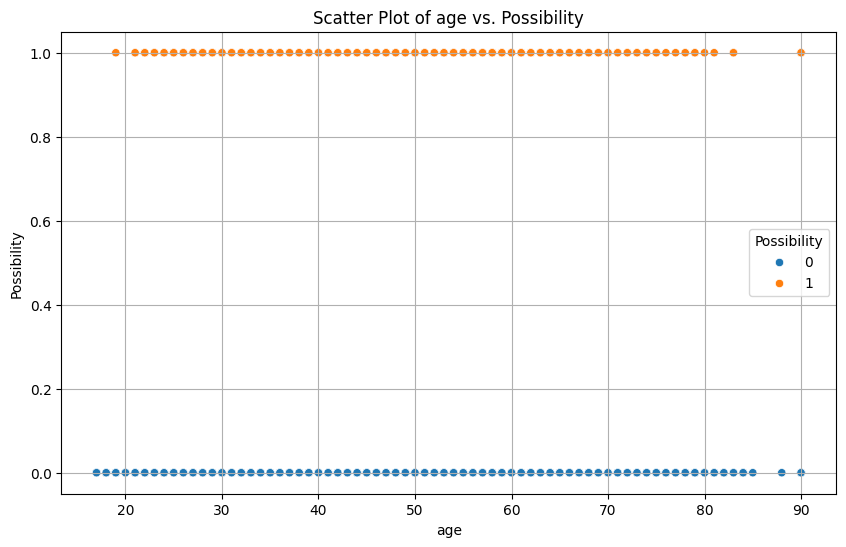

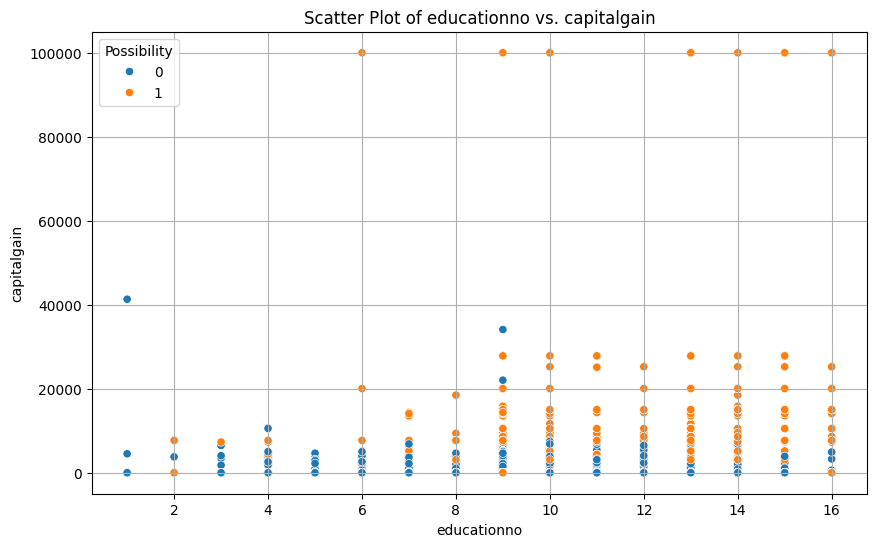

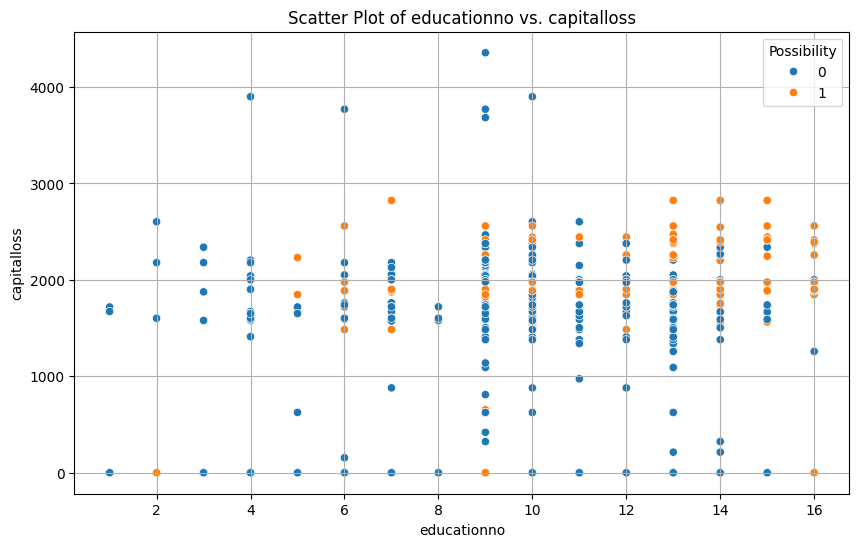

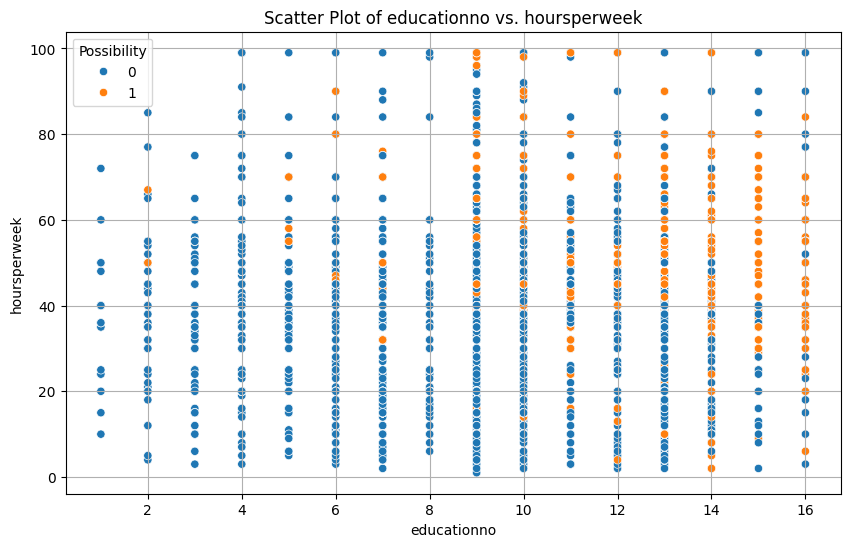

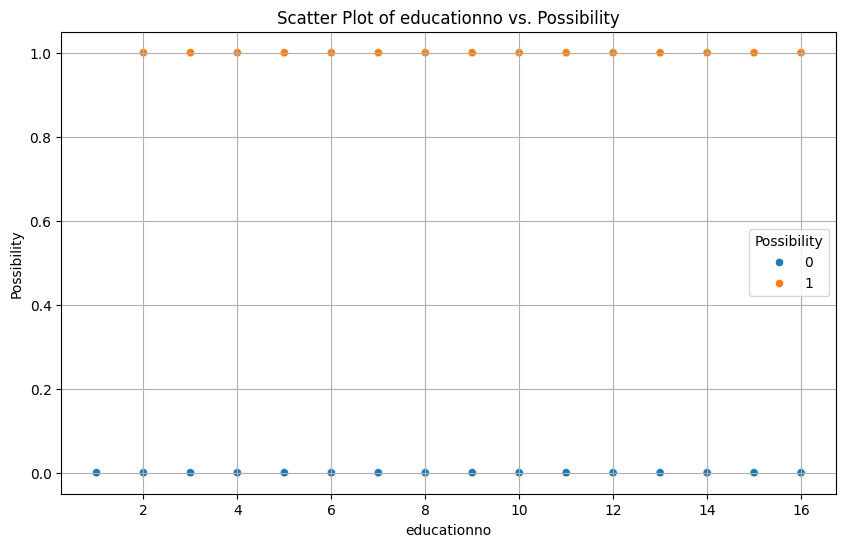

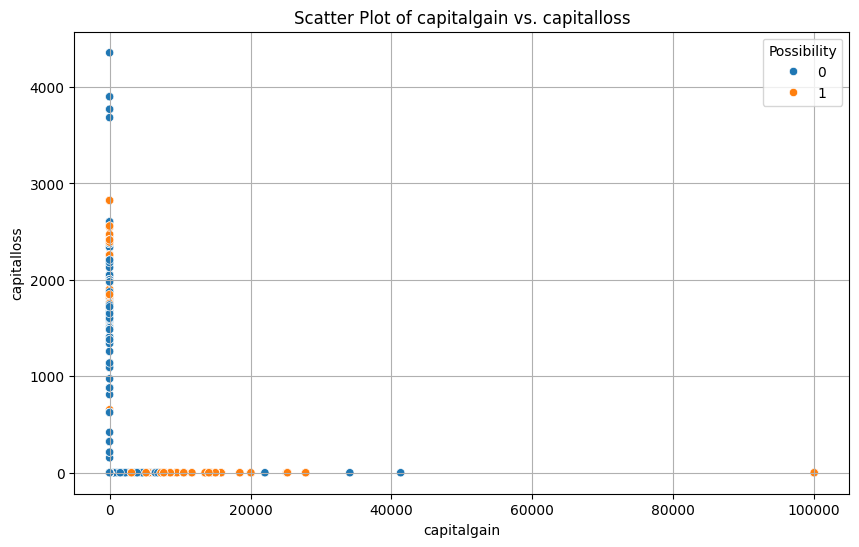

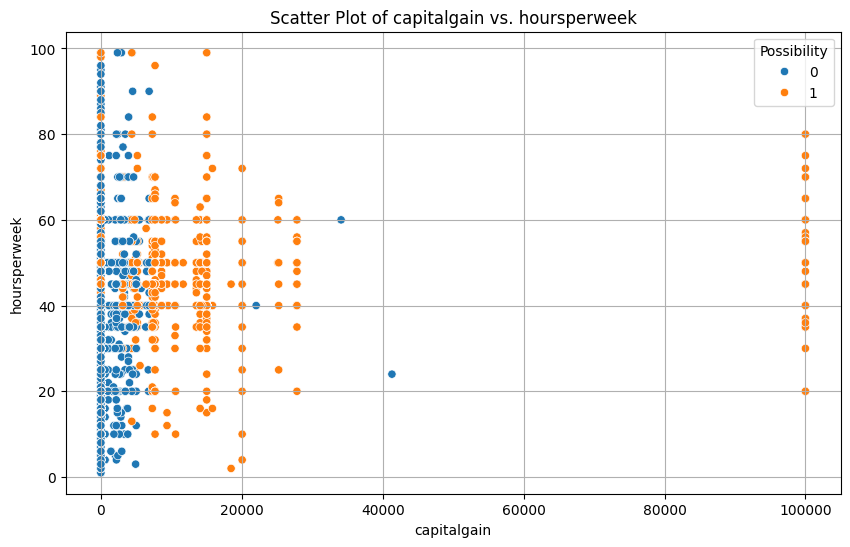

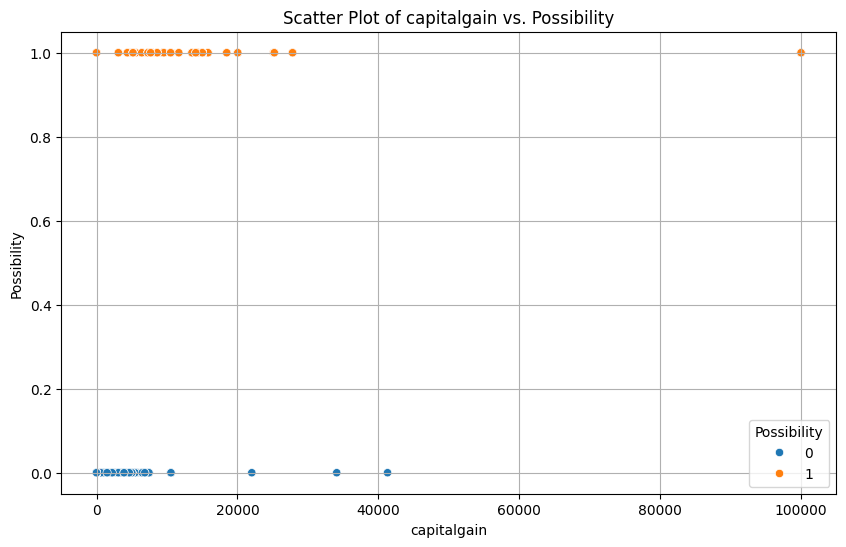

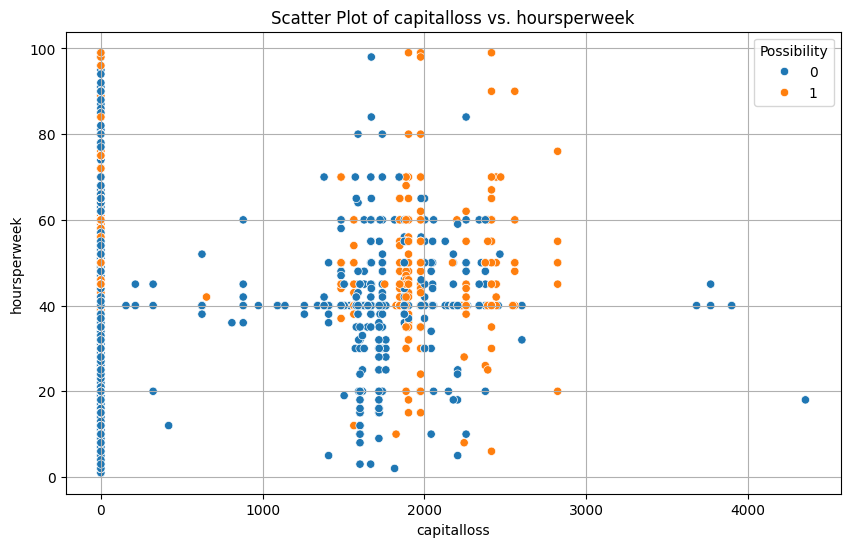

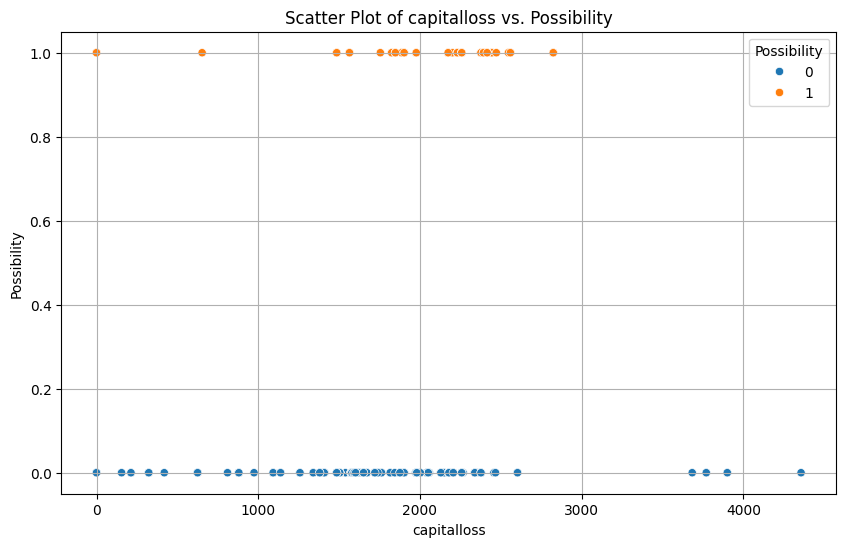

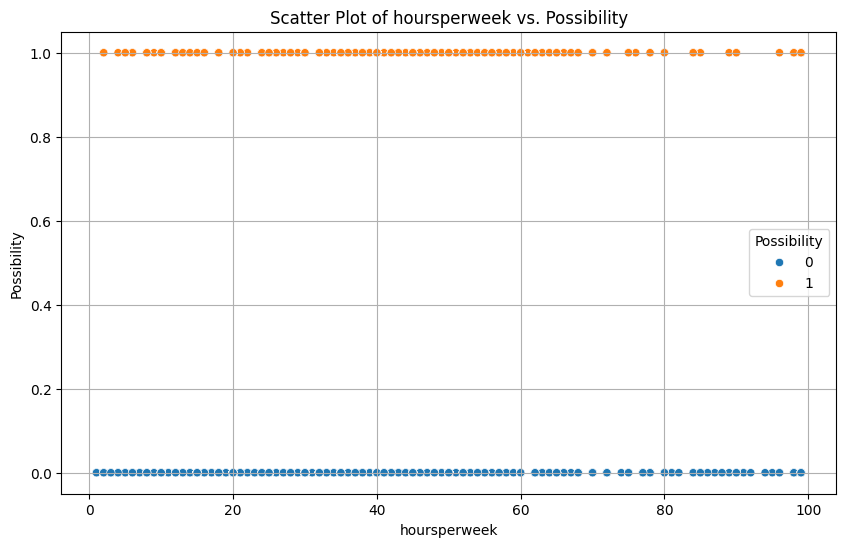

In [ ]:
for i in range(len(numerical_features)):
    for j in range(i + 1, len(numerical_features)):
        col1 = numerical_features[i]
        col2 = numerical_features[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2, hue='Possibility')  # You can change 'hue' to another categorical column
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.title(f'Scatter Plot of {col1} vs. {col2}')
        plt.grid(True)
        plt.show()

## Is the dataset imbalanced ?

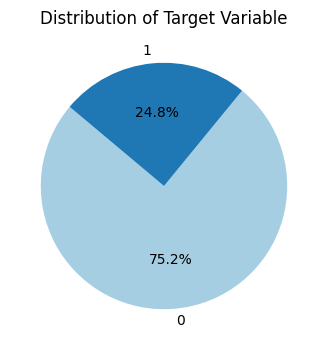

In [ ]:
# Count the occurrences of each category in the target variable
target_counts = df['Possibility'].value_counts()

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(target_counts))))
plt.title('Distribution of Target Variable')
plt.show()

**Observation :-**
Dataset is imbalanced. About 1/4th of the dataset contains potential criminals.

## 6) Finding Missing values

In [ ]:
missing_count = df.isnull().sum()
sorted_missing_count = missing_count.sort_values(ascending=False)
sorted_missing_count

,0
race,476
hoursperweek,318
sex,229
maritalstatus,136
age,0
workclass,0
education,0
educationno,0
occupation,0
relationship,0


In [ ]:
# Identify categorical columns. Datatypes that are either object or category are usually categorical in nature.
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Count instances for each categorical column
counts = {col: df[col].value_counts() for col in categorical_columns}

# Print the counts for each categorical column
for col, count in counts.items():
    print(f"Counts for '{col}':")
    print(count)
    print()

Counts for 'workclass':
workclass
Private             15585
Self-emp-not-inc     1767
Local-gov            1465
State-gov             909
Self-emp-inc          727
Federal-gov           647
Without-pay            12
Name: count, dtype: int64

Counts for 'education':
education
HS-grad         6791
Some-college    4714
Bachelors       3546
Masters         1124
Assoc-voc        911
Assoc-acdm       736
11th             734
10th             584
7th-8th          397
Prof-school      387
9th              331
Doctorate        268
12th             266
5th-6th          188
1st-4th          102
Preschool         33
Name: count, dtype: int64

Counts for 'maritalstatus':
maritalstatus
Married-civ-spouse       9740
Never-married            6874
Divorced                 2886
Separated                 641
Widowed                   556
Married-spouse-absent     267
Married-AF-spouse          12
Name: count, dtype: int64

Counts for 'occupation':
occupation
Craft-repair         2851
Prof-specialty     

## 3) Finding duplicates in the dataset

In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 1667


We can follow either of the 2 following strategies to deal with duplicates :-

a) Delete all duplicates of a row.\
b) Delete all but one, i.e, keep one of the duplicated rows.

## 4) Biases in dataset (if any)
Here we tried to find if the dataset got biased during collection. We focussed on the following :-

&emsp; a) How likely is it for non-Americans to be potential suspects ? <br>
&emsp; b) Is there any racial bias ? <br>

### a) How likely is it for non-Americans to be potential suspects ?

In [ ]:
def isAmerican(native):
  if native == "United-States":
    return 1
  else:
    return 0

df["IsAmerican"] = df["native"].apply(isAmerican)
df.head()

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native,Possibility,IsAmerican
0,35,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,1,1
1,23,Private,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,United-States,0,1
2,39,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,60.0,United-States,1,1
3,33,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,32.0,United-States,0,1
4,27,Self-emp-inc,HS-grad,9,Separated,Adm-clerical,Not-in-family,White,Male,0,0,38.0,United-States,0,1


In [ ]:
# Finding no.of Americans & Non-Americans
num_US_people = df["IsAmerican"].sum()
num_non_US_people = len(df) - num_US_people

# Finding no.of American potential guilty
condition1 = (df["Possibility"] == 1) & (df["IsAmerican"] == 1)
num_US_suspects = condition1.sum()

# Finding no.of non-American potential guilty
condition2 = (df["Possibility"] == 1) & (df["IsAmerican"] == 0)
num_non_US_suspects = condition2.sum()

print("Probability of an American to be potential criminal : {}".format(num_US_suspects/num_US_people))
print("Probability of a non-American to be potential criminal : {}".format(num_non_US_suspects/num_non_US_people))

Probability of an American to be potential criminal : 0.25331530500806076
Probability of a non-American to be potential criminal : 0.19543281996813594


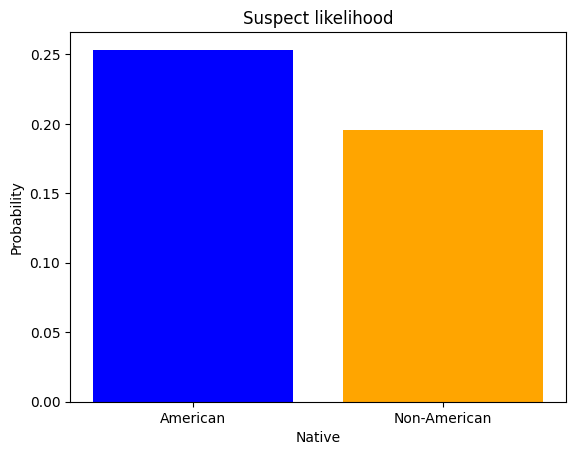

In [ ]:
probabs1 = [num_US_suspects/num_US_people, num_non_US_suspects/num_non_US_people]
labels1 = ['American', 'Non-American']

plt.bar(labels1, probabs1, color=['blue', 'orange'])

# Add labels and title
plt.xlabel('Native')
plt.ylabel('Probability')
plt.title('Suspect likelihood')

# Show the plot
plt.show()

### b) Is there any racial bias ?
Are white people more likely to be suspected than black people or people belonging to other racial groups ?

In [ ]:
def isWhite(race):
  if race == "White":
    return 1
  else:
    return 0

def isBlack(race):
  if race == "Black":
    return 1
  else:
    return 0

def isAsianPacIslander(race):
  if race == "Asian-Pac-Islander":
    return 1
  else:
    return 0

def isAmerIndianEskimo(race):
  if race == "Amer-Indian-Eskimo":
    return 1
  else:
    return 0

def isOther(race):
  if race == "Other":
    return 1
  else:
    return 0


df["IsWhite"] = df["race"].apply(isWhite)
df["IsBlack"] = df["race"].apply(isBlack)
df["IsAsianPacIslander"] = df["race"].apply(isAsianPacIslander)
df["IsAmerIndianEskimo"] = df["race"].apply(isAmerIndianEskimo)
df["IsOther"] = df["race"].apply(isOther)

num_white_people = df["IsWhite"].sum()
num_black_people = df["IsBlack"].sum()
num_asianpacisl_people = df["IsAsianPacIslander"].sum()
num_amer_indian_eskimo_people = df["IsAmerIndianEskimo"].sum()
num_other_people = df["IsOther"].sum()

condition3 = (df["Possibility"] == 1) & (df["IsWhite"]==1)
num_white_suspects = condition3.sum()

condition4 = (df["Possibility"] == 1) & (df["IsBlack"]==1)
num_black_suspects = condition4.sum()

condition5 = (df["Possibility"] == 1) & (df["IsAsianPacIslander"]==1)
num_asianpacisl_suspects = condition5.sum()

condition6 = (df["Possibility"] == 1) & (df["IsAmerIndianEskimo"]==1)
num_amerindianesk_suspects = condition6.sum()

condition7 = (df["Possibility"] == 1) & (df["IsOther"]==1)
num_other_suspects = condition7.sum()

print("Probability of an White to be potential criminal : {}".format(num_white_suspects/num_white_people))
print("Probability of a Black to be potential criminal : {}".format(num_black_suspects/num_black_people))
print("Probability of an Asian-Pac-Islander to be potential criminal : {}".format(num_asianpacisl_suspects/num_asianpacisl_people))
print("Probability of an Amer-Indian-Eskimo to be potential criminal : {}".format(num_amerindianesk_suspects/num_amer_indian_eskimo_people))
print("Probability of an Other to be potential criminal : {}".format(num_other_suspects/num_other_people))

Probability of an White to be potential criminal : 0.2630984004973718
Probability of a Black to be potential criminal : 0.1277922077922078
Probability of an Asian-Pac-Islander to be potential criminal : 0.27639751552795033
Probability of an Amer-Indian-Eskimo to be potential criminal : 0.13145539906103287
Probability of an Other to be potential criminal : 0.09316770186335403


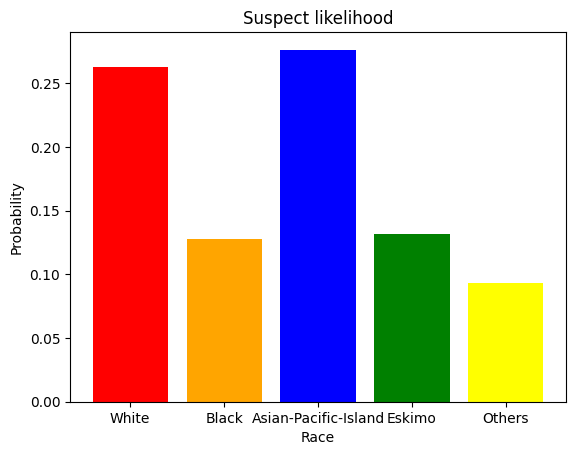

In [ ]:
probabs2 = [num_white_suspects/num_white_people, num_black_suspects/num_black_people, num_asianpacisl_suspects/num_asianpacisl_people,
            num_amerindianesk_suspects/num_amer_indian_eskimo_people, num_other_suspects/num_other_people]
labels2 = ['White', 'Black', 'Asian-Pacific-Island', 'Eskimo', 'Others']

plt.bar(labels2, probabs2, color=['red', 'orange', 'blue', 'green', 'yellow'])

# Add labels and title
plt.xlabel('Race')
plt.ylabel('Probability')
plt.title('Suspect likelihood')

# Show the plot
plt.show()

**Observations :-**<br>
1) Whites are twice more likely to be potential criminals than Blacks.

## 4)Data Cleaning

In [ ]:
import pandas as pd
df_train = pd.read_csv('/content/drive/MyDrive/train_data_90.csv')
df_test = pd.read_csv('/content/drive/MyDrive/test_data_90.csv')

### Checking presence of mixed datatypes

In [ ]:
def check_mixed_types(df, column_name):
    """Checks if a column in a DataFrame has mixed data types."""

    unique_types = df[column_name].apply(type).unique()
    # print(unique_types)
    return len(unique_types)

def drop_rows_with_float(df, column_name):
    """Drops rows where the specified column has float type data."""
    df_filtered = df[df[column_name].apply(type) != float ]
    return df_filtered

###Filter Train Set

In [ ]:
features = df_train.columns
for feature in features:
    mixed_types = check_mixed_types(df_train, feature)
    if mixed_types > 1:
        print(f"Column '{feature}' has '{mixed_types}' data types.")

df_filtered = drop_rows_with_float(df_train, 'maritalstatus')
df_filtered = drop_rows_with_float(df_filtered, 'race')
df_filtered = drop_rows_with_float(df_filtered, 'sex')

df_train_filtered = df_filtered
features = df_filtered.columns
for feature in features:
    mixed_types = check_mixed_types(df_train_filtered, feature)
    if mixed_types > 1:
        print(f"Column '{feature}' has '{mixed_types}' data types.")
df_train_filtered.shape


Column 'maritalstatus' has '2' data types.
Column 'race' has '2' data types.
Column 'sex' has '2' data types.


(26366, 14)

###Filter Test Set

In [ ]:
df_filtered = drop_rows_with_float(df_test, 'maritalstatus')
df_filtered = drop_rows_with_float(df_filtered, 'race')
df_filtered = drop_rows_with_float(df_filtered, 'sex')

df_test_filtered = df_filtered
features = df_filtered.columns
for feature in features:
    mixed_types = check_mixed_types(df_test_filtered, feature)
    if mixed_types > 1:
        print(f"Column '{feature}' has '{mixed_types}' data types.")


###Checking for missing values in each column

In [ ]:
df_train.isna().sum()

,0
age,0
workclass,0
education,0
educationno,0
maritalstatus,179
occupation,0
relationship,0
race,606
sex,303
capitalgain,0


### Finding the categorical features that are to be encoded using OHE and Frequency Encoding

In [ ]:
categorical_features = ['workclass', 'education', 'maritalstatus', 'occupation', 'relationship', 'race', 'sex', 'native']
continuous_features = ['age', 'educationno', 'capitalgain', 'capitalloss', 'hoursperweek']
ohe_features = ['maritalstatus','race','sex']
fe_features = ['workclass','education','occupation','relationship','native']

# 5) One Hot Encoding(OHE) and Frequency Encoding(FE)

###OHE and FE for Train Set

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# --- One-Hot Encoding ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_encoded = pd.DataFrame(ohe.fit_transform(df_train_filtered[ohe_features]))
ohe_encoded.columns = ohe.get_feature_names_out(ohe_features)
# --- Frequency Encoding ---
fe_encoded = df_train_filtered[fe_features].apply(lambda x: x.map(x.value_counts(normalize=True)))
# --- Combine and Drop ---
df_train_filtered = df_train_filtered.drop(ohe_features + fe_features, axis=1)
df_train_filtered = pd.concat([df_train_filtered, ohe_encoded, fe_encoded], axis=1)


### OHE and FE for Test Set

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# --- One-Hot Encoding ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_encoded = pd.DataFrame(ohe.fit_transform(df_test_filtered[ohe_features]))
ohe_encoded.columns = ohe.get_feature_names_out(ohe_features)

# --- Frequency Encoding ---
fe_encoded = df_test_filtered[fe_features].apply(lambda x: x.map(x.value_counts(normalize=True)))

# --- Combine and Drop ---
df_test_filtered = df_test_filtered.drop(ohe_features + fe_features, axis=1)
df_test_filtered = pd.concat([df_test_filtered, ohe_encoded, fe_encoded], axis=1)

### Split data into X(features) and y(label)

In [ ]:

X_train=df_train_filtered.drop(['Possibility','educationno'],axis=1)
y_train=df_train_filtered['Possibility']
X_test=df_test_filtered.drop(['Possibility','educationno'],axis=1)
y_test=df_test_filtered['Possibility']
X_train.shape,y_train.shape


((27118, 23), (27118,))

### Concatenating the encoded data for dropping duplicate values

In [ ]:
df2=pd.concat([X_train,y_train],axis=1)
df2=df2.drop_duplicates()
df2_test=pd.concat([X_test,y_test],axis=1)
df2_test=df2_test.drop_duplicates()
df2.shape,df2_test.shape


((25275, 24), (2920, 24))

### We found a new feature 'profit' by subtracting capitalloss from capitalgain and dropped these columns after adding profit

In [ ]:
df2['profit']=df2['capitalgain']-df2['capitalloss']
df2_test['profit']=df2_test['capitalgain']-df2_test['capitalloss']
df2=df2.drop(['capitalgain','capitalloss'],axis=1)
df2_test=df2_test.drop(['capitalgain','capitalloss'],axis=1)

### we dropped those rows where the 'Possibility' is set to Nan as we can't derive anything from an instance where the label is not present

In [ ]:
df2 = df2.dropna(subset=['Possibility'])
df2_test = df2_test.dropna(subset=['Possibility'])
X_train=df2.drop('Possibility',axis=1)
y_train=df2['Possibility']
X_test=df2_test.drop('Possibility',axis=1)
y_test=df2_test['Possibility']

In [ ]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((25236, 22), (25236,), (2903, 22), (2903,))

### Filled the remaining Nan values with median or 0 as per their utility

In [ ]:
for column in X_train.columns:
  if column == 'hoursperweek':
    X_train[column].fillna(0, inplace=True) # Fill NaNs in 'hoursperweek' with 0
  else:
    X_train[column].fillna(X_train[column].median(), inplace=True) # Fill NaNs in other columns with median



In [ ]:
for column in X_test.columns:
  if column == 'hoursperweek':
    X_test[column].fillna(0, inplace=True) # Fill NaNs in 'hoursperweek' with 0
  else:
    X_test[column].fillna(X_test[column].median(), inplace=True)

### Scaling the processed train and test data with MinMaxScaler

In [ ]:
common_features = X_train.columns.intersection(X_test.columns)
X_train = X_train[common_features]
X_test = X_test[common_features]
X_test = X_test[X_train.columns]
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
X_test_scaled.shape,y_test.shape,X_train_scaled.shape,y_train.shape

((2903, 22), (2903,), (25236, 22), (25236,))

### Finding importance of different features using a base Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                                Feature  Importance
0                                   age    0.218136
21                               profit    0.155603
19                         relationship    0.153003
18                           occupation    0.118559
1                          hoursperweek    0.108480
17                            education    0.092414
16                            workclass    0.045676
20                               native    0.018904
6           maritalstatus_Never-married    0.013292
4      maritalstatus_Married-civ-spouse    0.012991
15                             sex_Male    0.009643
14                           sex_Female    0.009404
2                maritalstatus_Divorced    0.009375
13                           race_White    0.008187
11                           race_Black    0.006840
7               maritalstatus_Separated    0.004585
8                 maritalstatus_Widowed    0.004277
10              race_Asian-Pac-Islander    0.003881
5   maritals

In [ ]:
important_features=['age','profit','relationship','occupation','hoursperweek','education','workclass']
X_train_imp=X_train_scaled[:,[X_train.columns.get_loc(c) for c in important_features]] # Get the integer index of each column name and use that to slice the NumPy array.
X_test_imp=X_test_scaled[:,[X_test.columns.get_loc(c) for c in important_features]] # Get the integer index of each column name and use that to slice the NumPy array.


## Naive Bayes from Scratch

In [ ]:
import numpy as np
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, f1_score

class GaussianNaiveBayes:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):

        self.classes = np.unique(y)
        self.means = {}
        self.variances = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.variances[c] = np.var(X_c, axis=0) + self.var_smoothing
            self.priors[c] = X_c.shape[0] / float(X.shape[0])

    def _predict_log_proba(self, X):

        log_probs = []
        for c in self.classes:
            mean = self.means[c]
            variance = self.variances[c]
            prior = np.log(self.priors[c])
            log_prob = -0.5 * np.sum(np.log(2. * np.pi * variance))
            log_prob -= 0.5 * np.sum(((X - mean) ** 2) / variance, axis=1)
            log_probs.append(log_prob + prior)
        return np.array(log_probs).T

    def predict(self, X):

        log_probs = self._predict_log_proba(X)
        return self.classes[np.argmax(log_probs, axis=1)]

    def predict_proba(self, X):

        log_probs = self._predict_log_proba(X)
        # Convert log probabilities to probabilities
        exp_log_probs = np.exp(log_probs - np.max(log_probs, axis=1, keepdims=True))
        return exp_log_probs / np.sum(exp_log_probs, axis=1, keepdims=True)

    def get_params(self, deep=True):
        return {"var_smoothing": self.var_smoothing}

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self


# Assuming X_train, X_test, y_train, y_test are defined
X_train, y_train = X_train_imp, y_train
X_test, y_test = X_test_imp, y_test

# Apply ADASYN to balance the training data
adasyn = ADASYN(n_neighbors=5,random_state=42)
X_train_balanced, y_train_balanced = adasyn.fit_resample(X_train, y_train)

# Initialize and fit the Gaussian Naive Bayes model
model_NBS = GaussianNaiveBayes(var_smoothing=1e-9)
model_NBS.fit(X_train_balanced, y_train_balanced)

# Predict on the test set
y_pred = model_NBS.predict(X_test)
accuracy_NBS = accuracy_score(y_test, y_pred)
f1_NBS = f1_score(y_test, y_pred,average='weighted')

# Print evaluation metrics
print(f"Gaussian Naive Bayes Accuracy: {accuracy_NBS}")
print(f"Gaussian Naive Bayes F1 score: {f1_NBS}")

Gaussian Naive Bayes Accuracy: 0.7977953840854288
Gaussian Naive Bayes F1 score: 0.767530430344599


## Naive Bayes Sklearn

In [ ]:
from sklearn.naive_bayes import GaussianNB
model_NB=GaussianNB()
X_train,y_train=X_train_imp,y_train
model_NB.fit(X_train_imp,y_train)
y_pred=model_NB.predict(X_test_imp)
accuracy_NB=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy_NB}")
f1_NB = f1_score(y_test, y_pred,average='weighted')
print(f"F1 score: {f1_NB}")

Accuracy:0.7881501894591801
F1 score: 0.7397241328215985


## SVC Sklearn

In [ ]:
from sklearn.svm import SVC
sv=SVC(kernel='rbf',C=3,gamma='scale',class_weight='balanced',degree=5)
sv.fit(X_train_imp,y_train)

y_pred=sv.predict(X_test_imp)
accuracy_SV=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy_SV}")
f1_SV = f1_score(y_test, y_pred,average='weighted')
print(f"F1 score: {f1_SV}")

Accuracy:0.7636927316569067
F1 score: 0.7778895627520043


## Decision Tree Sklearn

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier(criterion='gini',min_samples_split=5,min_samples_leaf=3,max_features='sqrt',max_depth=10)
dc.fit(X_train_imp,y_train)
y_pred=dc.predict(X_test_imp)
accuracy_DT=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy_DT}")
f1_DT = f1_score(y_test, y_pred,average='weighted')
print(f"F1 score: {f1_DT}")

Accuracy:0.8460213572166724
F1 score: 0.8367356834947468


## KNN Sklearn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
knn = KNeighborsClassifier(n_neighbors=20)
accuracy_scores_KNN = cross_val_score(knn, X_train_imp, y_train, cv=5, scoring='accuracy')
print(f"Average accuracy: {accuracy_scores_KNN.mean()}")
knn.fit(X_train_imp,y_train)
y_pred = knn.predict(X_test)
accuracy_KNN = accuracy_score(y_test, y_pred)
f1_KNN = f1_score(y_test, y_pred,average='weighted')
print(f"F1 score: {f1_KNN}")

Average accuracy: 0.819741623666222
F1 score: 0.8116769173735736


## Ensemble Model From Scratch Containing Scratch Gradient Boosting, Naive Bayes ,Sklearn KNN,SVC and Decision Tree

### Gradient Boosting Code from Scratch

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.metrics import make_scorer, accuracy_score

class GradientBoostingClassifier:
    def __init__(self, n_estimators=200, learning_rate=0.05, max_depth=10):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        # Initialize with log(odds)
        self.initial_prediction = np.log(np.sum(y == 1) / np.sum(y == 0))
        predictions = np.full(len(X), self.initial_prediction)

        for _ in range(self.n_estimators):
            # Calculate negative gradient (residuals)
            residuals = y - 1 / (1 + np.exp(-predictions))

            # Fit a tree to the residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
            self.trees.append(tree)

            # Update predictions
            predictions += self.learning_rate * tree.predict(X)

    def predict(self, X):
        predictions = np.full(len(X), self.initial_prediction)

        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)

        # Convert log(odds) to probabilities and then to class labels
        probabilities = 1 / (1 + np.exp(-predictions))
        return (probabilities > 0.5).astype(int)
    def get_params(self, deep=True):
        return {
            'n_estimators': self.n_estimators,
            'learning_rate': self.learning_rate,
            'max_depth': self.max_depth,
        }

    # Add set_params method
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

# Define a custom scorer for cross-validation
def accuracy_scorer(model, X, y):
    y_pred = model.predict(X)
    return accuracy_score(y, y_pred)



### Final Ensemble Model using Voting Classifier

In [ ]:

from sklearn.base import BaseEstimator, ClassifierMixin # Import necessary classes
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
class VotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, classifiers):
        self.classifiers = classifiers

    def fit(self, X, y):
        for clf in self.classifiers:
            clf.fit(X, y)
        return self

    def predict(self, X):
        predictions = np.array([clf.predict(X) for clf in self.classifiers])
        predictions = predictions.astype(int)
        majority_vote = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)
        return majority_vote

    def predict_proba(self, X):
        probs = np.array([clf.predict_proba(X) for clf in self.classifiers])
        avg_probs = np.mean(probs, axis=0)
        return avg_probs

# Initialize individual classifiers
nb_clf = GaussianNaiveBayes(var_smoothing=1e-9)
svc_clf = SVC(kernel='rbf',class_weight='balanced',probability=True, random_state=42,gamma='scale')
knn_clf = KNeighborsClassifier(n_neighbors=10,n_jobs=-1)
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    max_depth=10,
    random_state=42
    )
gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=10)

# Initialize the VotingClassifier
voting_clf = VotingClassifier(classifiers=[nb_clf, svc_clf, knn_clf, dt_clf, gb_clf])

X_train, y_train = X_train_imp, y_train
X_test, y_test = X_test_imp, y_test

# Fit the VotingClassifier
voting_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = voting_clf.predict(X_test)
accuracy_Ensemble = accuracy_score(y_test, y_pred)
f1_Ensemble = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Voting Classifier Accuracy: {accuracy_Ensemble}")
print(f"Voting Classifier F1 score: {f1_Ensemble}")

Voting Classifier Accuracy: 0.8529107819497072
Voting Classifier F1 score: 0.845676847422148


## Plot for Accuracies of our models

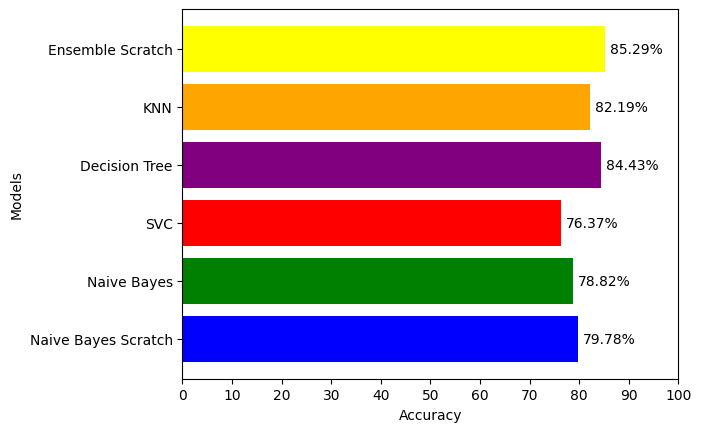

In [ ]:
import matplotlib.pyplot as plt
accuracies=[accuracy_NBS,accuracy_NB,accuracy_SV,accuracy_DT,accuracy_KNN,accuracy_Ensemble]
models=['Naive Bayes Scratch','Naive Bayes','SVC','Decision Tree','KNN','Ensemble Scratch']
colors = ['blue', 'green', 'red', 'purple', 'orange','yellow']
bars = plt.barh(models, accuracies, color=colors)
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{accuracy*100:.2f}%', va='center')
plt.ylabel('Models')
plt.xlabel('Accuracy')
#plt.title('Comparison of Accuracies')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1), np.arange(0, 110, 10))
plt.show()

##Plot for f1 scores of our models

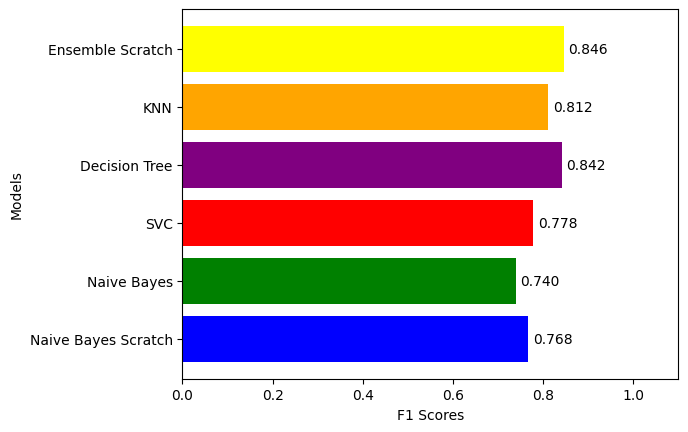

In [ ]:
f1_scores=[f1_NBS,f1_NB,f1_SV,f1_DT,f1_KNN,f1_Ensemble]
models=['Naive Bayes Scratch','Naive Bayes','SVC','Decision Tree','KNN','Ensemble Scratch']
colors = ['blue', 'green', 'red', 'purple', 'orange','yellow']
bars = plt.barh(models, f1_scores, color=colors)
for bar, f1_score in zip(bars, f1_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{f1_score:.3f}', va='center')
plt.ylabel('Models')
plt.xlabel('F1 Scores')
#plt.title('Comparison of F1_Scores')
plt.xlim(0, 1.1)
plt.show()